## Random Recombination

In [1]:
# dictionaries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import truncnorm, lognorm, gamma

/Users/elisaheinrichmora/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Two Locus Model

In [24]:
def two_locus_simulation(p_init, r, n_gens):
    """
    Simulates a two-locus population over multiple generations, considering selection and recombination.
    
    Parameters:
        p_init (array-like): Initial haplotype frequencies [p_AB, p_Ab, p_aB, p_ab].
        r (float): Recombination rate between loci.
        n_gens (int): Number of generations to simulate.
    
    Returns:
        np.ndarray: A matrix containing allele frequencies and linkage disequilibrium (D) over generations.
    """
    # Initialize storage for allele frequencies and linkage disequilibrium values
    p_array = np.zeros((n_gens, 4), dtype=np.float64)
    D_array = np.zeros(n_gens, dtype=np.float64)
    p_array[0] = p_init  # Set initial haplotype frequencies

    for gen in range(1, n_gens):
        prev_p = p_array[gen - 1]  # Previous generation haplotype frequencies
        
        # Compute marginal fitness of each haplotype
        w_marg = np.sum(selection_matrix() * prev_p, axis=1)
        
        # Compute linkage disequilibrium (D)
        p_A = prev_p[0] + prev_p[1]  # p_A = p_AB + p_Ab
        p_B = prev_p[0] + prev_p[2]  # p_B = p_AB + p_aB
        D = prev_p[0] - (p_A * p_B)
        D_array[gen] = D  # Store D value for this generation

        # Vector capturing the effect of recombination on allele frequencies
        D_vec = np.array([-D, +D, +D, -D], dtype=np.float64)
        
        # Compute mean population fitness
        w_bar = np.sum(w_marg * prev_p)
        
        # Update allele frequencies, incorporating selection and recombination
        p_new = (w_marg * prev_p + r * D_vec) / w_bar
        
        # Normalize to ensure probabilities sum to 1
        p_new /= np.sum(p_new)
        p_array[gen] = p_new
    
    # Return combined results: haplotype frequencies and linkage disequilibrium over generations
    return np.column_stack((p_array, D_array))

In [25]:
def selection_matrix(s=0.9):
    """
    Generates a selection matrix encoding relative fitness values for diploid genotypes.
    
    Parameters:
        s (float): Selection coefficient (default: 0.5).
    
    Returns:
        np.ndarray: A 4x4 selection matrix representing fitness values.
    """
    return np.array([
        [(1-s)**2, (1-s), (1-s), 1],
        [(1-s), (1-s)**2, 1, (1-s)],
        [(1-s), 1, (1-s)**2, (1-s)],
        [1, (1-s), (1-s), (1-s)**2]
    ])

In [26]:
def plot_allele_frequencies(allele_freqs, r):
    """
    Plots allele frequencies over generations.
    
    Parameters:
        allele_freqs (np.ndarray): Array containing allele frequencies over generations.
        r (float): Recombination rate used in the simulation.
    """
    generations = np.arange(allele_freqs.shape[0])
    labels = ['AB', 'Ab', 'aB', 'ab']
    
    plt.figure()
    for i in range(4):
        plt.plot(generations, allele_freqs[:, i], label=labels[i])
    
    plt.xlabel('Generations')
    plt.ylabel('Frequency')
    plt.title(f'Allele Frequencies Over Generations (r={r})')
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
def plot_recombination_vs_linkage_disequilibrium(p_init, r_values, n_gens):
    """
    Plots recombination rates against final linkage disequilibrium (D) values.
    
    Parameters:
        p_init (array-like): Initial haplotype frequencies.
        r_values (array-like): Array of recombination rates.
        n_gens (int): Number of generations to simulate.
    """
    D_values = [two_locus_simulation(p_init, r, n_gens)[-1, -1] for r in r_values]
    
    plt.figure()
    plt.plot(r_values, D_values, marker='o')
    plt.xlabel('Recombination Rate (r)')
    plt.ylabel('Linkage Disequilibrium (D)')
    plt.title('Recombination Rate vs. Linkage Disequilibrium')
    plt.grid(True)
    plt.show()

In [28]:
def plot_D_over_generations(result):
    """
    Plots the change in linkage disequilibrium (D) over generations.
    
    Parameters:
        result (np.ndarray): Output from two_locus_simulation containing D values.
    """
    generations = np.arange(len(result))
    D_values = result[:, -1]  # Extract the D values (last column)
    
    plt.figure()
    plt.plot(generations, D_values, label='D values', color='r')
    plt.xlabel('Generations')
    plt.ylabel('Linkage Disequilibrium (D)')
    plt.title('Changes in Linkage Disequilibrium Over Generations')
    plt.grid(True)
    plt.legend()
    plt.show()


### Figure 1

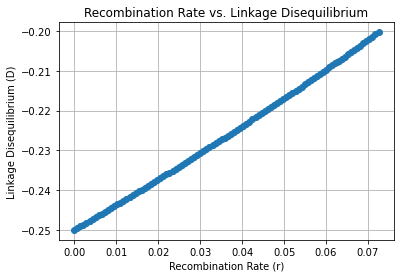

In [37]:
l= 2*(2*s)- (2*(2*s-s**2))
s = 0.9
p = np.array([0.1, 0.2, 0.3, 0.4], dtype=np.float64)  # Initial allele frequencies
n_gens = 500000
r_ = np.linspace(0, l/8+0.01, 100) 
r_values = np.append(r_, l/8)
r_values.sort()

plot_recombination_vs_linkage_disequilibrium(p, r_values, n_gens)

In [64]:
(0.05)**2

0.0025000000000000005

In [65]:
.14*.14

0.019600000000000003